# Project 2 — Goodreads Book Recommender

<small>EDA → collaborative filtering vs a popularity baseline (RMSE + Precision/Recall@N) → an **LLM re-ranking layer** that personalizes the Top-N to a stated preference. Reproducible from `data/Books.csv` and `data/Ratings.csv`. The logic lives in `src/`; this notebook is the narrative that becomes `app.py`.</small>


## Step 0 — Setup


In [6]:
from pathlib import Path
import subprocess
import sys


def _find_bookrec_dir(start: Path) -> Path:
    for path in (start, *start.parents):
        if (path / "requirements.txt").exists() and (path / "src").exists():
            return path
        if (path / "bookrec" / "requirements.txt").exists() and (path / "bookrec" / "src").exists():
            return path / "bookrec"
    raise FileNotFoundError("Could not find bookrec/requirements.txt")


BOOKREC_DIR = _find_bookrec_dir(Path.cwd())
requirements_file = BOOKREC_DIR / "requirements.txt"

subprocess.check_call([
    sys.executable,
    "-m",
    "pip",
    "install",
    "-r",
    str(requirements_file),
    "matplotlib",
])


0

In [7]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))   # so `from src import ...` works from notebooks/
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
from src import data_loader, cf_model, evaluate, recommend, llm_rerank
pd.set_option('display.max_colwidth', 55)


## Step 1 — Load the data
Reads the two assignment CSVs and repairs the author-name encoding.


In [8]:
ratings, books = data_loader.load('../data')
print('ratings:', ratings.shape, '| books:', books.shape)
print('users:', ratings.user_id.nunique(), '| rated books:', ratings.book_id.nunique())
books[['book_id','title','authors','original_publication_year','average_rating','ratings_count']].head()


ratings: (164728, 3) | books: (9964, 17)
users: 1192 | rated books: 9229


,book_id,title,authors,original_publication_year,average_rating,ratings_count
0,1,"The Hunger Games (The Hunger Games, #1)",Suzanne Collins,2008.0,4.34,4942365
1,2,Harry Potter and the Sorcerer's Stone (Harry Potter...,"J.K. Rowling, Mary GrandPré",1997.0,4.44,4800065
2,3,"Twilight (Twilight, #1)",Stephenie Meyer,2005.0,3.57,3916824
3,4,To Kill a Mockingbird,Harper Lee,1960.0,4.25,3340896
4,5,The Great Gatsby,F. Scott Fitzgerald,1925.0,3.89,2773745


## Step 2 — Exploratory data analysis
Look at users, ratings, and books, and note what each implies for modeling.


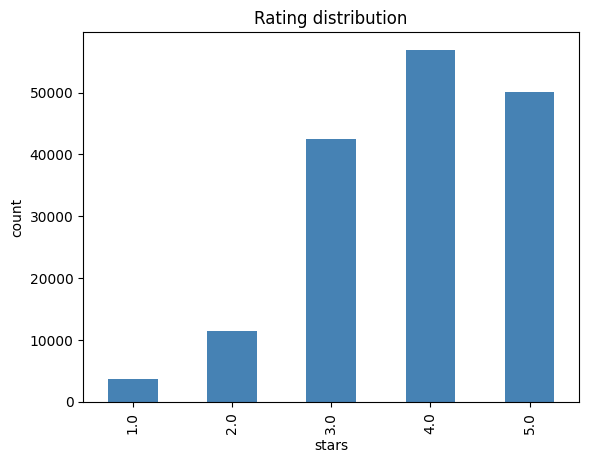

count    164728.000000
mean          3.840495
std           1.008316
min           1.000000
25%           3.000000
50%           4.000000
75%           5.000000
max           5.000000
Name: rating, dtype: float64
65.0% of ratings are 4★ or 5★ → strong popularity / mean baseline


In [9]:
# Rating distribution — skew toward 4–5★ (MNAR: people rate books they expect to like)
rc = ratings['rating'].value_counts().sort_index()
pct_high = 100 * rc.loc[[4.0, 5.0]].sum() / len(ratings)
ax = rc.plot(kind='bar', color='steelblue')
ax.set_title('Rating distribution'); ax.set_xlabel('stars'); ax.set_ylabel('count'); plt.show()
print(ratings['rating'].describe())
print(f'{pct_high:.1f}% of ratings are 4★ or 5★ → strong popularity / mean baseline')


In [10]:
# Sparsity + activity: ratings per user and per book
n_users, n_books_rated = ratings.user_id.nunique(), ratings.book_id.nunique()
n_cells = n_users * len(books)
sparsity = 1 - len(ratings) / n_cells
per_user = ratings.groupby('user_id').size()
per_book = ratings.groupby('book_id').size()
cold_books = set(books.book_id) - set(ratings.book_id)
print(f'users: {n_users:,} | books in catalog: {len(books):,} | books with ≥1 rating: {n_books_rated:,}')
print(f'ratings/user  -> median {per_user.median():.0f}, max {per_user.max()}')
print(f'ratings/book  -> median {per_book.median():.0f}, max {per_book.max()}')
print(f'matrix sparsity: {sparsity:.2%}  (only {len(ratings)/n_cells:.4%} of cells filled)')
print(f'cold items (never rated in log): {len(cold_books):,} books ({100*len(cold_books)/len(books):.1f}% of catalog)')


users: 1,192 | books in catalog: 9,964 | books with ≥1 rating: 9,229
ratings/user  -> median 129, max 200
ratings/book  -> median 8, max 100
matrix sparsity: 98.61%  (only 1.3869% of cells filled)
cold items (never rated in log): 735 books (7.4% of catalog)


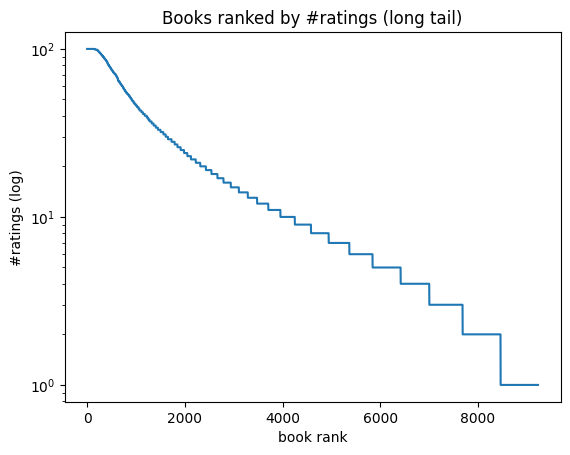

Top 10 books account for 0.6% of all ratings in the log


In [11]:
# Popularity long tail: a few books soak up most ratings
ranked = per_book.sort_values(ascending=False).reset_index(drop=True)
ranked.plot(title='Books ranked by #ratings (long tail)', logy=True)
plt.xlabel('book rank'); plt.ylabel('#ratings (log)'); plt.show()
top10_share = ranked.head(10).sum() / ranked.sum()
print(f'Top 10 books account for {100*top10_share:.1f}% of all ratings in the log')


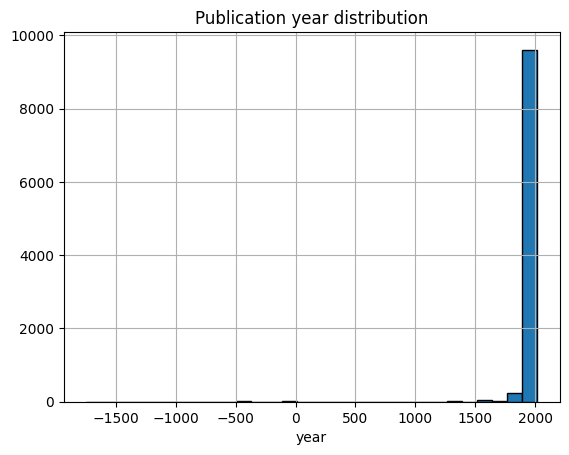

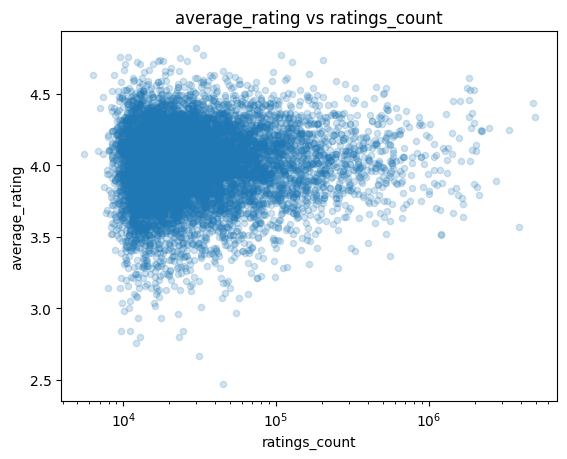

language mix:
language_code
eng      6322
en-US    2062
en-GB     256
ara        64
en-CA      58
Name: count, dtype: int64
before load(): J.K. Rowling, Mary GrandPrÃ©
after  load(): Stephenie Meyer


In [12]:
# Publication year + quality vs popularity; encoding fix sanity check
books['original_publication_year'].dropna().astype(int).hist(bins=30, edgecolor='k')
plt.title('Publication year distribution'); plt.xlabel('year'); plt.show()
books.plot.scatter(x='ratings_count', y='average_rating', alpha=0.2, logx=True,
                   title='average_rating vs ratings_count'); plt.show()
print('language mix:'); print(books['language_code'].value_counts().head())
# Encoding: load() repairs mojibake (latin-1 misread as UTF-8)
raw = pd.read_csv('../data/Books.csv', usecols=['book_id','authors']).set_index('book_id')
print('before load():', raw.loc[2, 'authors'])
print('after  load():', books.loc[2, 'authors'])


### EDA takeaways
- **~65%** of ratings are 4–5★ (MNAR) → popularity/mean is a **strong baseline**; CF must clear it on ranking metrics too.
- Matrix **~98.5% sparse**; median **8** ratings/book → item-based CF struggles on the long tail.
- **735 cold books** (never in the rating log) → content/metadata helps; pure CF cannot recommend them from behavior alone.
- **Popularity long tail** — head books dominate → watch popularity bias and catalog coverage.
- `average_rating` is compressed (~3.5–4.5); weak separation vs `ratings_count`.
- **No shelf tags** in this dataset → content model uses title + authors only (`tags` is empty).
- Author **encoding** needed cleaning (`load(fix_encoding=True)` repairs GrandPré-style mojibake).

## Step 3 — Models: popularity baseline, BaselineOnly, UBCF, IBCF, SVD
Popularity/mean (pure Python) plus `surprise` models. Held-out split (`random_state=6604`) for RMSE and Top-N ranking metrics.


In [13]:
train, test = evaluate.train_test_split_ratings(ratings, test_size=0.1, seed=6604)

models = {'Popularity': cf_model.PopularityModel().fit(train)}
try:
    cf_model._require_surprise()
    models.update({
        'BaselineOnly': cf_model.CFModel('baseline').fit(train),
        'UBCF': cf_model.CFModel('ubcf').fit(train),
        'IBCF': cf_model.CFModel('ibcf').fit(train),
        'SVD': cf_model.CFModel('svd').fit(train),
    })
except ImportError as e:
    print('scikit-surprise not available — Popularity-only comparison.', e)

comparison = evaluate.compare_cf_models(train, test, models, k=10, threshold=4.0)
comparison


,RMSE,Precision@10,Recall@10,NDCG@10
model,,,,
Popularity,0.9815,0.6524,0.7910,0.8001
BaselineOnly,0.8378,0.6539,0.7926,0.8048
UBCF,1.0270,0.6547,0.7928,0.8053
IBCF,0.9408,0.6107,0.7395,0.7204
SVD,0.8386,0.6534,0.7925,0.8060


## Step 4 — Interpret the comparison table
**RMSE** = rating accuracy on held-out stars. **Precision/Recall/NDCG@10** = Top-N quality (relevant = test rating ≥ 4). They often disagree — tune and report both.


In [14]:
# Pick the best CF model by NDCG@10 (change metric if your story differs)
best_name = comparison['NDCG@10'].idxmax()
best = models[best_name]
print(f'Best on NDCG@10: {best_name}')
comparison.sort_values('NDCG@10', ascending=False)


Best on NDCG@10: SVD


,RMSE,Precision@10,Recall@10,NDCG@10
model,,,,
SVD,0.8386,0.6534,0.7925,0.8060
UBCF,1.0270,0.6547,0.7928,0.8053
BaselineOnly,0.8378,0.6539,0.7926,0.8048
Popularity,0.9815,0.6524,0.7910,0.8001
IBCF,0.9408,0.6107,0.7395,0.7204


**Interpretation (write this up).** If the popularity baseline is hard to beat, that's the expected outcome on a sparse, popularity-skewed dataset — explain *why* (sparsity, cold items, head dominance) and what it implies for model selection. This honest analysis is worth points.


## Step 5 (optional extra) — Hybrid: TF-IDF vs semantic embeddings
Content vectors live **in memory** (no ChromaDB). `backend="embeddings"` needs `pip install sentence-transformers`.

In [15]:
from src.content_model import ContentModel
from src.hybrid import HybridRecommender

content_tfidf = ContentModel(backend='tfidf').fit(books)
hybrid_tfidf = HybridRecommender(cf_model=best, content_model=content_tfidf, alpha=0.6)

uid_h = ratings.user_id.value_counts().index[0]
ur = ratings[ratings.user_id == uid_h]
cands = [b for b in books.book_id if b not in set(ur.book_id)]
hybrid_scores = hybrid_tfidf.score(uid_h, ur, cands).sort_values(ascending=False).head(5)
print('Hybrid (TF-IDF +', best_name, '):')
print(hybrid_scores)

try:
    content_emb = ContentModel(backend='embeddings').fit(books)
    hybrid_emb = HybridRecommender(cf_model=best, content_model=content_emb, alpha=0.6)
    emb_scores = hybrid_emb.score(uid_h, ur, cands).sort_values(ascending=False).head(5)
    print('\nHybrid (sentence-transformers +', best_name, '):')
    print(emb_scores)
except ImportError:
    print('\nSkipping embeddings backend — install sentence-transformers to compare.')

Hybrid (TF-IDF + SVD ):
1308    0.696953
2101    0.694833
4653    0.689700
862     0.686645
779     0.686334
Name: hybrid_score, dtype: float64

Skipping embeddings backend — install sentence-transformers to compare.


## Step 6 — Top-N from the best CF model, then the LLM layer
Pick the best model, generate a user's Top-N, then re-rank to a stated preference.


In [16]:
# `best` and `best_name` come from Step 4

class A:  # tiny adapter so recommend_top_n can use the raw model
    content = None
    def __init__(s, m): s.m = m
    def score(s, u, ur, ids): return s.m.predict_for_user(u, ids)

uid = ratings.user_id.value_counts().index[0]   # an active user
cf_recs = recommend.recommend_top_n(uid, A(best), ratings, books, top_n=10, min_ratings=50, explain=False)
cf_recs[['book_id','title','authors','score']]


,book_id,title,authors,score
0,862,"Words of Radiance (The Stormlight Archive, #2)",Brandon Sanderson,4.2443
1,779,A Fine Balance,Rohinton Mistry,4.2422
2,192,"The Name of the Wind (The Kingkiller Chronicle, #1)",Patrick Rothfuss,4.1424
3,1342,"Night Watch (Discworld, #29; City Watch, #6)",Terry Pratchett,4.1413
4,267,The Nightingale,Kristin Hannah,4.0831
5,144,"Unbroken: A World War II Story of Survival, Resilie...",Laura Hillenbrand,4.0170
6,1274,The Night Before Christmas,"Clement C. Moore, Jan Brett",4.0160
7,307,"The Wise Man's Fear (The Kingkiller Chronicle, #2)",Patrick Rothfuss,3.9968
8,31,The Help,Kathryn Stockett,3.9956
9,998,The Monster at the End of this Book,"Jon Stone, Michael J. Smollin",3.9809


In [17]:
# LLM re-ranking: candidates -> Gemini (if GEMINI_API_KEY set) else heuristic fallback.
# Set your key in the environment first (never in code):  export GEMINI_API_KEY=...
cands = llm_rerank.candidates_from_recs(cf_recs, books)
picks, used_llm = llm_rerank.rerank(cands, preference='something dark and mysterious', top_k=5)
print('source:', 'Gemini LLM' if used_llm else 'heuristic fallback (no key)')
for i, p in enumerate(picks, 1):
    print(f'{i}. {p.title} — {p.authors}')
    print(f'   why: {p.explanation}')


source: heuristic fallback (no key)
1. Words of Radiance (The Stormlight Archive, #2) — Brandon Sanderson
   why: matches “something dark and mysterious” on its title/author
2. Unbroken: A World War II Story of Survival, Resilience, and Redemption — Laura Hillenbrand
   why: matches “something dark and mysterious” on its title/author
3. A Fine Balance — Rohinton Mistry
   why: top collaborative-filtering pick for this user
4. The Name of the Wind (The Kingkiller Chronicle, #1) — Patrick Rothfuss
   why: top collaborative-filtering pick for this user
5. Night Watch (Discworld, #29; City Watch, #6) — Terry Pratchett
   why: top collaborative-filtering pick for this user


## Step 7 — From notebook to Streamlit
This exact flow (pick user → CF Top-N → LLM re-rank) is wired in `../app.py`:

```bash
cd ..
export GEMINI_API_KEY=your_key_here   # optional; without it the app uses the fallback
streamlit run app.py
```

See `PROJECT_FRAMEWORK.md` for the rubric map and `docs/LLM_RERANK.md` for the grounded prompt strategy.

**Vectors:** content similarity stays in memory (`content_model.py`) — no ChromaDB at this catalog size.
